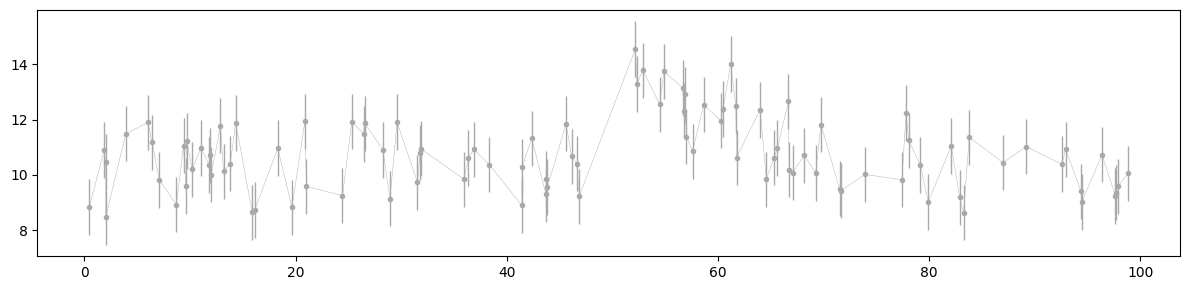

In [1]:
### Setting Things Up

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

infile = '../solutions/transient.npy'
data = np.load(infile)
time, flux, yerr = data[:,0], data[:,1], data[:,2]
fig, axs = plt.subplots(tight_layout=True, figsize=(12,3))
_ = axs.errorbar(time, flux, yerr=yerr, marker='.', lw=0.3, elinewidth=1, c='darkgray')

In [2]:
from numba import njit, float64
import scipy
from scipy.stats import uniform

uGrid = np.linspace(0, 1, 10000)
ppf_bkg      = np.array( scipy.stats.uniform(0, 50).ppf(uGrid) )
ppf_bAmpl    = np.array( scipy.stats.uniform(0, 50).ppf(uGrid) ) ### Squeezing the domain from 50 to 15.
ppf_t0       = np.array( scipy.stats.uniform(0,100).ppf(uGrid) ) 
ppf_logAlpha = np.array( scipy.stats.uniform(-3, 3).ppf(uGrid) ) ### Squeezing the domain from -5,5 to -3,+3

ppf_gAmpl    = np.array( scipy.stats.uniform(1, 10).ppf(uGrid) )
ppf_sigmaW   = np.array( scipy.stats.uniform(3, 10).ppf(uGrid) )

@njit(float64[:](float64[:]))
def uPrior_1(params):
    x0 = ppf_bkg     [ ( np.abs(uGrid - params[0]) ).argmin() ]
    x1 = ppf_bAmpl   [ ( np.abs(uGrid - params[1]) ).argmin() ]
    x2 = ppf_t0      [ ( np.abs(uGrid - params[2]) ).argmin() ]
    x3 = ppf_logAlpha[ ( np.abs(uGrid - params[3]) ).argmin() ]
    return np.array([x0, x1, x2,x3]) 

@njit(float64(float64, float64[:]))
def Model_1(t, params):
    bkg, bAmpl, t0, logalpha = params
    if t < t0: return bkg
    alpha = 10**logalpha
    return bkg + bAmpl*np.exp(-alpha*(t-t0))

@njit(float64(float64[:]))
def logLikelihood_1(params):
    logL = 0
    for t, f, rms in zip(time, flux, yerr):
        logL = logL - ( f - Model_1(t, params) )**2 / 2*np.pi/rms**2 - 0.5*np.log10(2*np.pi*rms**2)
    if np.isnan(logL) == True: return -np.inf
    return logL

@njit(float64[:](float64[:]))
def uPrior_2(params):
    x0 = ppf_bkg   [ ( np.abs(uGrid - params[0]) ).argmin() ]
    x1 = ppf_gAmpl [ ( np.abs(uGrid - params[1]) ).argmin() ]
    x2 = ppf_t0    [ ( np.abs(uGrid - params[2]) ).argmin() ]
    x3 = ppf_sigmaW[ ( np.abs(uGrid - params[3]) ).argmin() ]
    return np.array([x0, x1, x2,x3]) 

@njit(float64(float64, float64[:]))
def Model_2(t, params):
    bkg, gAmpl, t0, sigmaW = params
    return bkg + gAmpl*np.exp(-(t-t0)**2 / (2 * sigmaW**2) )

@njit(float64(float64[:]))
def logLikelihood_2(params):
    logL = 0
    for t, f, rms in zip(time, flux, yerr):
        logL = logL - ( f - Model_2(t, params) )**2 / 2*np.pi/rms**2 - 0.5*np.log10(2*np.pi*rms**2)
    if np.isnan(logL) == True: return -np.inf
    return logL

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [52:49<00:00, 31.69s/it]


(array([ 2.,  7.,  8., 14., 13., 19., 17.,  9.,  5.,  6.]),
 array([-209.59690284, -209.49213619, -209.38736953, -209.28260288,
        -209.17783623, -209.07306958, -208.96830292, -208.86353627,
        -208.75876962, -208.65400297, -208.54923631]),
 <BarContainer object of 10 artists>)

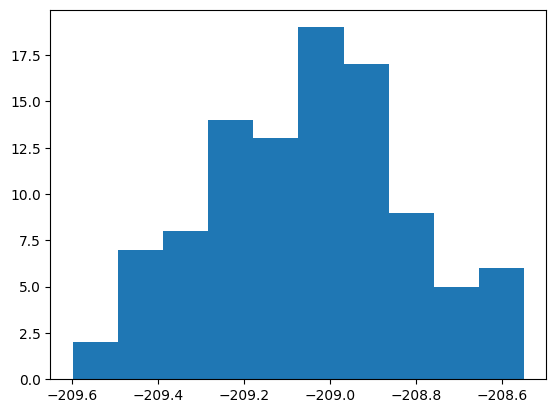

In [8]:
### I would like to compare the performance of a nested sampler by changing the number of livepoints

import dynesty
import warnings
warnings.filterwarnings("ignore") ### Ruthless, but very effective!
ndim = 4
N = 100
logZ = np.zeros(N)

from tqdm import tqdm
for _ in tqdm( range(N) ):#np.logspace(2, 3, 5, dtype=int):
    sampler = dynesty.NestedSampler(logLikelihood_1, uPrior_1, ndim, nlive=250)
    #sampler_1 = dynesty.DynamicNestedSampler(logLikelihood_1, uPrior_1, ndim)
    sampler.run_nested(print_progress=False)
    sresults = sampler.results
    logZ[_] = sresults.logz[-1]

0.2293573828798886


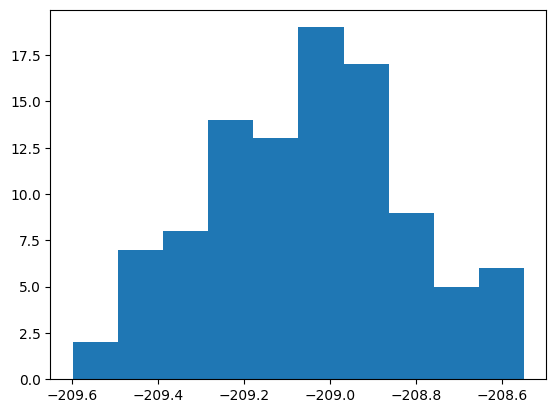

In [12]:
plt.hist(logZ)
print(np.var(logZ)**0.5)